In [17]:
import torch
import matplotlib.pyplot as plt    

# ***Linear Regression*** 

In [113]:
#parameters
w=2
b=-3

step=0.1
start=-1
end=1

x=torch.arange(start,end,step)
y=w*x+b

# prepare for datasets

train_num=int(0.8*len(x))

train_x=x[:train_num]
train_y=y[:train_num]
test_x=x[train_num:]
test_y=y[train_num:]

test_x,test_y


(tensor([0.6000, 0.7000, 0.8000, 0.9000]),
 tensor([-1.8000, -1.6000, -1.4000, -1.2000]))

### **`Plotting with Matplotlib: Converting PyTorch Tensors`**

#### **The Problem:**

Matplotlib works with **NumPy arrays**, but PyTorch uses **tensors**. Some tensors also have:
- `requires_grad=True` (gradient tracking)
-  Located on GPU (cuda device)

**Matplotlib cannot handle:**
- GPU tensors
- Tensors with gradients
- PyTorch tensor objects directly

---

### **The Solution: Convert Tensors Properly**

For any tensor, always do this before plotting:
- **`tensor = tensor.detach().cpu().numpy()`**

In [170]:
def plot_predictions(x_train=train_x.detach().cpu().numpy(),
                     y_train=train_y.detach().cpu().numpy(),
                     x_test=test_x.detach().cpu().numpy(), 
                     y_test=test_y.detach().cpu().numpy(),
                     predictions=None):
    """
    Plot training data, test data, and model predictions
    
    Args:
        x_train: Training input data
        y_train: Training target data
        x_test: Test input data
        y_test: Test target data
        predictions: Model predictions (optional)
    """


    plt.figure(figsize=(5, 4))
    
    # Plot training data
    plt.scatter(x_train, y_train, c='red', alpha=0.6, label='Training data', s=20)
    
    # Plot test data
    plt.scatter(x_test, y_test, c='black', alpha=0.6, label='Test data', s=20)
    
    # Plot predictions if provided
    if predictions is not None:
        # Sort for smoother line
        sorted_indices = torch.argsort(x_test.squeeze())
        x_sorted = x_test[sorted_indices]
        y_sorted = predictions[sorted_indices]
        
        plt.scatter(x_test, predictions, c='b', label='Predictions', alpha=0.8,s=20)
    
    # Add labels and title
    plt.xlabel('x', fontsize=12)
    plt.ylabel('y', fontsize=12)
    plt.title('Data Visualization', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return plt

<module 'matplotlib.pyplot' from '/home/luojie13x/miniconda3/envs/dl_course/lib/python3.9/site-packages/matplotlib/pyplot.py'>

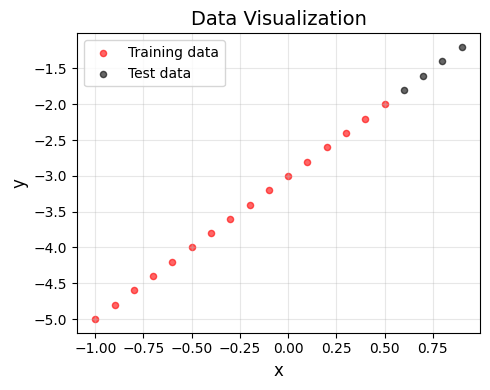

In [21]:
plot_predictions(train_x,train_y,test_x,test_y)

# BUILD MODLE !

#### ***Check what is inside our model using `.parameters()`***


In [137]:
import torch
import torch.nn as nn


torch.manual_seed(42)

class LinearRegressionModel(nn.Module):  # Inherits from nn.Module
    def __init__(self):
        super().__init__()  # Call parent's __init__
        
        # Create learnable parameters
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float32))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float32))
    
    def forward(self, x:torch.Tensor)->torch.Tensor:  # ← IMPORTANT: This must be at class level, not inside __init__
        return self.weights * x + self.bias

# Create model
model = LinearRegressionModel()


with torch.inference_mode():  # turns off gradient tracking
        # 1. do the forward pass
        pred_without_train=model(test_x)

#plot_predictions(train_x,train_y,test_x,test_y,pred_without_train)

## **Let's figure out what's inside the nn.Module**
> - `self._parameters={}`    # _Stores learnable parameters (weights, biases)_
> - `def __call__(self,*input)`
---
#### This is a __SIMPLIFIED version__ of what `nn.Module` looks like inside:
```python

class MyModule:
    def __init__(self):
        print("  MyModule.__init__ running")
        
        # These are the internal dictionaries that store everything
        self._parameters = {}      # Stores learnable parameters (weights, biases)
        self._modules = {}         # Stores submodules (layers like Linear, Conv)
        self._buffers = {}         # Stores non-learnable tensors (like running_mean)
        self.training = True       # Training mode flag
        self._device = None        # Current device (cpu/cuda)
        self._version = 0          # Version number
    
    def __setattr__(self, name, value):
        # This is the magic! When you do self.weights = nn.Parameter(...)
        # This method automatically adds it to self._parameters
        if isinstance(value, nn.Parameter):
            self._parameters[name] = value
        # Then set the attribute normally
        super().__setattr__(name, value)
    
    def __call__(self, *input):
        # This makes model(x) work!
        print("  MyModule.__call__ running")
        return self.forward(*input)
    
    def forward(self, *input):
        # This should be overridden by your class
        raise NotImplementedError("Subclasses must implement forward()")
    
    def parameters(self):
        # Returns all learnable parameters
        for param in self._parameters.values():
            yield param
        for module in self._modules.values():
            yield from module.parameters()
    
    def cuda(self):
        # Move all parameters to GPU
        print("  Moving parameters to GPU")
        for param in self._parameters.values():
            param.data = param.data.cuda()
        return self
    
    def state_dict(self):
        # Returns all parameters as a dictionary (for saving)
        return {name: param.data for name, param in self._parameters.items()}

# **The core to train the model**
https://docs.pytorch.org/docs/stable/nn.html
> - #### **Loss Function:** https://docs.pytorch.org/docs/stable/nn.html#loss-functions
> - #### **Optimizer:** https://docs.pytorch.org/docs/stable/optim.html
    
> - #### **Training Loop:**
> - #### **Testing Loop:**



## **Optimizer**
**torch.optim.Optimizer(params,defaults)**
#### **Optimizer Parameters:** based on `Algorithms` to use(e.g. **`Adam`**, **`SGD`**)
> - `params(iterable)`
> - `lr`: learning rate



# Building a Training Loop - Complete Guide

### The 4 Essential Steps (In Order)

| Step | Name | What it does |
|------|------|--------------|
| 1 | **Forward Pass** | Make predictions using current weights |
| 2 | **Calculate Loss** | Measure how wrong predictions are |
| 3 | **Backward Pass** | Calculate gradients (how to change weights) |
| 4 | **Update Weights** | Adjust weights to reduce loss |

---

## Detailed Explanation of Each Step

### Step 1: Forward Pass
- **Purpose**: Get predictions from your model
- **Input**: Training data (x)
- **Output**: Predictions (y_pred)
- **Formula**: `y_pred = model(x)`
- **What happens**: Data flows through the network using current weights

### Step 2: Calculate Loss
- **Purpose**: Quantify the error
- **Input**: Predictions (y_pred) and true values (y_true)
- **Output**: A single number (loss)
- **Formula**: `loss = loss_fn(y_pred, y_true)`
- **What happens**: Compares predictions to truth; larger loss = worse predictions

### Step 3: Back Propagation (Gradient Calculation)
- **Purpose**: Determine how to change each weight
- **Sub-step A - Zero Gradients**: `optimizer.zero_grad()`
  - Clears old gradient values from previous batch
  - Without this, gradients accumulate incorrectly
- **Sub-step B - Backward**: `loss.backward()`
  - Calculates ∂loss/∂weight for every parameter
  - Uses chain rule from calculus
  - Tells direction to move each weight (up or down)
- **Output**: Gradients stored in `.grad` of each parameter

### Step 4: Update Weights
- **Purpose**: Apply gradients to improve model
- **Formula**: `optimizer.step()`
- **What it does**: `weight_new = weight_old - learning_rate × gradient`
- **Result**: Weights move in direction that reduces loss

---

## The Correct Order (Why It Matters)

**Key Points:**
- `zero_grad()` must come BEFORE `backward()` (not after)
- `backward()` must come BEFORE `step()` (not after)
- `step()` is always last

---
## Optional but Common Additions

| Addition | Code | Purpose |
|----------|------|---------|
| Progress printing | `if epoch % 100 == 0: print(loss)` | Monitor training |
| Loss storage | `losses.append(loss.item())` | Plot later |
| Validation | `with torch.no_grad(): val_pred = model(x_val)` | Check overfitting |
| Batch loop | `for batch in dataloader:` | Handle large datasets |
| Learning rate scheduling | `scheduler.step()` | Adjust learning rate |

---

## Common Mistakes

| Mistake | Consequence | Fix |
|---------|-------------|-----|
| Forgetting `zero_grad()` | Gradients accumulate, training fails | Always call before `backward()` |
| Wrong order (step before backward) | Updates based on old gradients | Always `backward()` then `step()` |
| No `loss.item()` when printing | Prints tensor, not number | Use `loss.item()` for number |
| Training without `model.train()` | BatchNorm/Dropout wrong mode | Call `model.train()` before loop |

---

In [34]:
model.state_dict()

OrderedDict([('weights', tensor([-1.0789])), ('bias', tensor([0.4834]))])

In [138]:
# track the training process

epoch_count = []
train_loss_values = []
test_loss_values = []

# set up a loss function
loss_fn=nn.MSELoss()


# set up a optimizer
optimizer=torch.optim.SGD(
    params=model.parameters(),
    lr=0.01
)

epochs=1000

for epoch in range(epochs):

    epoch_count.append(epoch)
    # TRAINING PHASE
    # set the model to training mode
    model.train()  # ← Enable Dropout, BatchNorm uses batch stats

    # 1.Forward pass
    y_pred=model(train_x)

    # 2.Calculate Loss
    loss=loss_fn(y_pred,train_y)
    train_loss_values.append(loss.item())
    
    # 3.Gradient Calculation
    # A.optimizer zero grad
    optimizer.zero_grad()

    # B.perform backpropagation on the loss with respect to the parameters of the model
    loss.backward()

    # 4.Update Weights
    optimizer.step()

    # TESTING/EVALUATION PHASE
    #  Sets model to evaluation mode
    model.eval() # ← Disable Dropout, BatchNorm uses running stats
    with torch.inference_mode():  # turns off gradient tracking
        # 1. do the forward pass
        test_pred=model(test_x)

        # 2. calculate the loss
        test_loss=loss_fn(test_pred,test_y)
        test_loss_values.append(test_loss.item())

        # 3. to see what is going on
        if epoch % 20 ==0:
            print(f"Epoch:{epoch} | Loss:{loss} | Test_loss:{test_loss}")
            #print(model.state_dict())

Epoch:0 | Loss:13.152352333068848 | Test_loss:3.3789048194885254
Epoch:20 | Loss:5.537961006164551 | Test_loss:1.0164201259613037
Epoch:40 | Loss:2.3479106426239014 | Test_loss:0.23777267336845398
Epoch:60 | Loss:1.0090768337249756 | Test_loss:0.02999058924615383
Epoch:80 | Loss:0.4451669454574585 | Test_loss:0.007317596115171909
Epoch:100 | Loss:0.20593780279159546 | Test_loss:0.030913405120372772
Epoch:120 | Loss:0.10299573093652725 | Test_loss:0.05602111294865608
Epoch:140 | Loss:0.05747613310813904 | Test_loss:0.071762815117836
Epoch:160 | Loss:0.036333464086055756 | Test_loss:0.0781770646572113
Epoch:180 | Loss:0.025693487375974655 | Test_loss:0.07793999463319778
Epoch:200 | Loss:0.01970897801220417 | Test_loss:0.07368966937065125
Epoch:220 | Loss:0.015895826742053032 | Test_loss:0.06737680733203888
Epoch:240 | Loss:0.013182315975427628 | Test_loss:0.06027194485068321
Epoch:260 | Loss:0.011092313565313816 | Test_loss:0.05313482880592346
Epoch:280 | Loss:0.009402659721672535 | Test

<module 'matplotlib.pyplot' from '/home/luojie13x/miniconda3/envs/dl_course/lib/python3.9/site-packages/matplotlib/pyplot.py'>

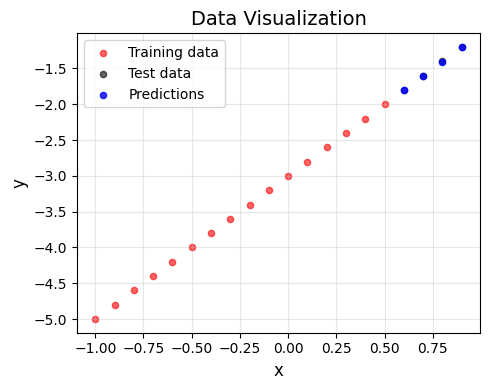

In [135]:
# make predictions with model
with torch.inference_mode():  # turns off gradient tracking
    y_preds=model(test_x)

plot_predictions(train_x,train_y,test_x,test_y,y_preds)

<module 'matplotlib.pyplot' from '/home/luojie13x/miniconda3/envs/dl_course/lib/python3.9/site-packages/matplotlib/pyplot.py'>

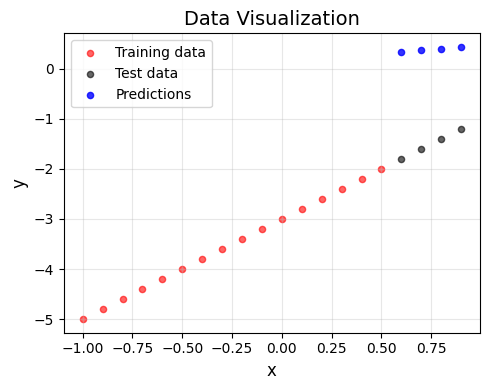

In [78]:
plot_predictions(train_x,train_y,test_x,test_y,pred_without_train)

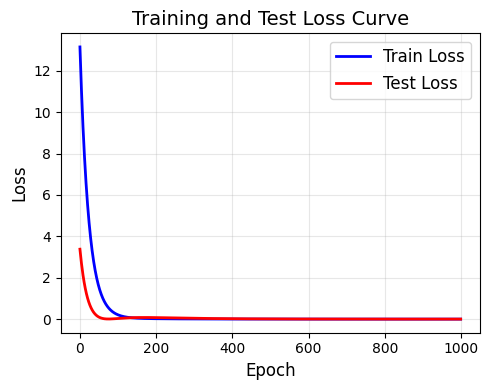

In [151]:
import numpy as np
plt.figure(figsize=(5, 4))
plt.plot(epoch_count, train_loss_values, label="Train Loss", color='blue', linewidth=2)
plt.plot(epoch_count, test_loss_values, label="Test Loss", color='red', linewidth=2)
plt.title("Training and Test Loss Curve", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **Save and load the model** 

https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html

**`state_dict:`** A Python dictionary that stores all the learnable parameters (weights and biases) of your model.
- **A. state_dict for model**
```python 
model.state_dict()

# Print all weights and biases
for name, param in model.state_dict().items():
    print(f"{name}: {param}")
```

- **B. state_dict for optimizer**
  - *Hyperparameters (learning rate, momentum)*
  - *Internal states (momentum buffers)*

```python
optimizer.state_dict()

for name, value in optimizer.state_dict().items():
    print(f"  {name}: {value}")
```


**`torch.save(obj, f, pickle_module=pickle, pickle_protocol=2, _use_new_zipfile_serialization=True)`**

`Parameters:`
- **obj** : saved object
- **f** : file path

- **Case 1 : Save only Model Weights (recommended)**

```python
import torch
import torch.nn as nn

# Save
torch.save(model.state_dict(), 'model_weights.pth')

# Load
model = YourModelClass()  # Must recreate architecture first!
model.load_state_dict(torch.load('model_weights.pth'))
model.eval()  # Set to evaluation mode


```
- **Case 2 : Save Model + Optimizer State  (For Resuming Training)**

```python
# Save checkpoint
checkpoint = {
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': loss,
    'other_info': {'notes': 'experiment_001'}
}
torch.save(checkpoint, 'checkpoint.pth')

# Load checkpoint
checkpoint = torch.load('checkpoint.pth')
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
loss = checkpoint['loss']
print(f"Resumed from epoch {epoch}, loss = {loss:.4f}")

```
- **Case 3 : Save Entire Model (Not Recommended)**

```python
# Save entire model (architecture + weights)
torch.save(model, 'entire_model.pth')

# Load entire model
model = torch.load('entire_model.pth')
model.eval()

```
**`torch.load(f, map_location=None, pickle_module=pickle, *, weights_only=True, mmap=None, **pickle_load_args)`**
`Parameters:`
- **f** : saved object,  just the file path
- **map_location** : torch.device, cpu/cuda/specified cuda(e.g. cuda:0)


In [150]:
# save our model
from pathlib import Path

# A. save only the weights
folder_path = Path('models') / 'weights_only'
folder_path.mkdir(parents=True,exist_ok=True)

save_path=folder_path / '01_model.pth'
torch.save(model.state_dict(),save_path)

# B. save the checkpoints

folder_path2= Path('models') / 'checkpoints'
folder_path2.mkdir(parents=True,exist_ok=True)
save_path2=folder_path2 / '01_model_check_points.pth'

checkpoint = {
    'epoch':epoch,
    'optimizer_state_dict':optimizer.state_dict(),
    'model_state_dict':model.state_dict(),
    'loss':loss
}

torch.save(checkpoint,save_path2)

# C.save the whole model

folder_path3=Path('models') / 'completed_model'
folder_path3.mkdir(parents=True,exist_ok=True)

save_path3=folder_path3 / '01_completed_model.pth'
torch.save(model,save_path3)



In [174]:
# Load the model
model_load = LinearRegressionModel()

if torch.cuda.is_available():
    model_load.cuda()
    model_load.load_state_dict(torch.load(save_path, map_location='cuda:0'))
    test_x=test_x.cuda()
else:
    model_load.load_state_dict(torch.load(f=save_path, map_location='cpu'))

model_load.eval()


y_pred_load_model=model_load(test_x)
y_pred_load_model,y_pred_new


# Convert tensors for plotting
#y_pred_plot = y_pred_load_model.detach().cpu()

# Now plot
#plot_predictions(train_x_plot, train_y_plot, test_x_plot, test_y_plot, y_pred_plot)

(tensor([-1.8110, -1.6122, -1.4134, -1.2146], device='cuda:0',
        grad_fn=<AddBackward0>),
 tensor([[-1.7947],
         [-1.5945],
         [-1.3942],
         [-1.1940]]))